# Motivation 

I decided to use some transforms for the data before trying to detect any features, because during one of the Info (2P6) supervisions my supervisor mentioned that so many datasets can be simplified if represented in terms of a transform (mainly DFT).

I got interested in this, and thought it may be easier to recognise certain features via a transform. It didn't work quite as expected, but this way I found out about Gabor Wavelets as a way to recognise small-scale features (and the phase congruency method that builds upon this).

It was also a good starting point to start reading a book on image processing properly.. 

0. Upload a ''destriped'' image from the detection file (as it contains preprocessing algorithms)

In [1]:
%%capture
%run "./npy-data-QD-DETECTION.ipynb"

Sometimes files don't connect very well, so in the following cell I'm checking if needed files exist and have data (even though z_destriped_2d is underlined in yellow on my computer):

In [4]:
print(
    "z_destriped_2d exists:",
    "z_destriped_2d" in globals(),
)

if "z_destriped_2d" in globals():
    print(
        "Shape:",
        z_destriped_2d.shape,
    )
    print(
        "Range:",
        np.nanmin(z_destriped_2d),
        np.nanmax(z_destriped_2d),
    )

z_destriped_2d exists: True
Shape: (512, 512)
Range: -3.3282065936524867e-09 3.7102728061034956e-09


# Taking transforms of data and applying filters to them

## Fourier Transform

Running FFT for a random image. Need to subtract the average height because otherwise we will just get a black image on the output since the average (0 frequency, or the DC component) will dominate this. Apparently, this is common in AFM.

For quantum dots FFT is mostly usedful for: 
1. Detecting periodicity/ order 
2. Detecting scan artefacts
3. separating length scales 
4. estimating characteristic dot spacing -> HOW 
5. Designing filters 

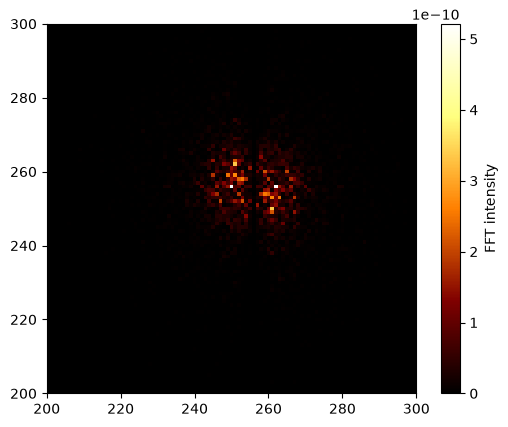

In [6]:
import numpy as np
import matplotlib.pyplot as plt

import numpy as np
import matplotlib.pyplot as plt
import cv2

from skimage.filters import gaussian
from skimage.feature import blob_log


z_nobackground = z_destriped_2d - np.mean(z_destriped_2d)
F = np.fft.fftshift(np.fft.fft2(z_nobackground))

power = np.abs(F)**2

plt.imshow(np.log(power + 1), cmap="afmhot")
plt.colorbar(label="FFT intensity")

plt.xlim(200, 300)
plt.ylim(200, 300)

plt.show()

However, the range is very high. So, lets take the magnitude and plot it on the log scale: 

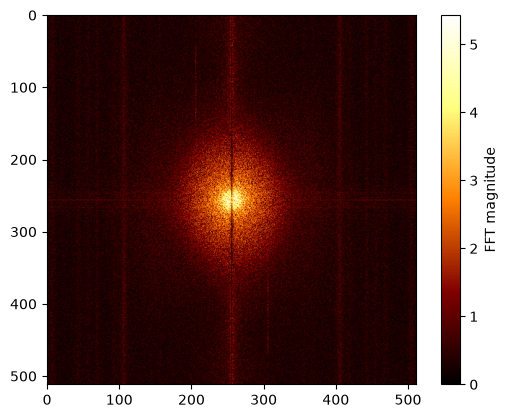

In [7]:
magnitude = np.abs(F)*10e6

plt.imshow(
    np.log1p(magnitude),
    cmap="afmhot"
)

plt.colorbar(label="FFT magnitude")
plt.show()

Using Gaussian filtering, remove the low-frequency background

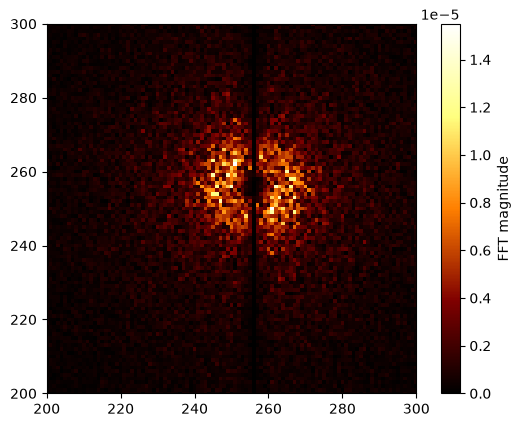

In [8]:
from scipy.ndimage import gaussian_filter

background = gaussian_filter(z_destriped_2d, sigma=20)

z_filtered = z_destriped_2d - background

F = np.fft.fftshift(np.fft.fft2(z_filtered))

plt.imshow(
    np.log1p(np.abs(F)),
    cmap="afmhot"
)

plt.colorbar(label="FFT magnitude")

plt.xlim(200, 300)
plt.ylim(200, 300)

plt.show()

FFT band-pass filter function testing

Quantum dots appear as halo effect on the FFT, so we can quantify them using FFT or at least try finding their characteristics

The distance from the center corresponds to the inverse of your spatial distances 1/lambda. The angle of the spots indicates the alignment direction of the dots (e.g., self-assembled linear chains along specific crystallographic step edges) 
https://www.sciencedirect.com/science/article/pii/S0169433223001940?__cf_chl_f_tk=YJBFMlXXGtf3M5XObAKVd4wQ49Iv38h0nNXggozaJw0-1783435783-1.0.1.1-FPUAAJPymiutSDDc3XulPfOcpp64fsEhst8XZy4TOx8 

## Discrete Cosine Transform

I shifted this to the centre, so that some analogy can be seen between this and the FT representation of the signal.
However, DCT doesnt store positive and negative frequencies separately as cosine is an even function. Furthermore, reversing the frequency gives the same pattern. SO WE ONLY HAVE ONE QUADRANT OF DCT REPRESENTATION

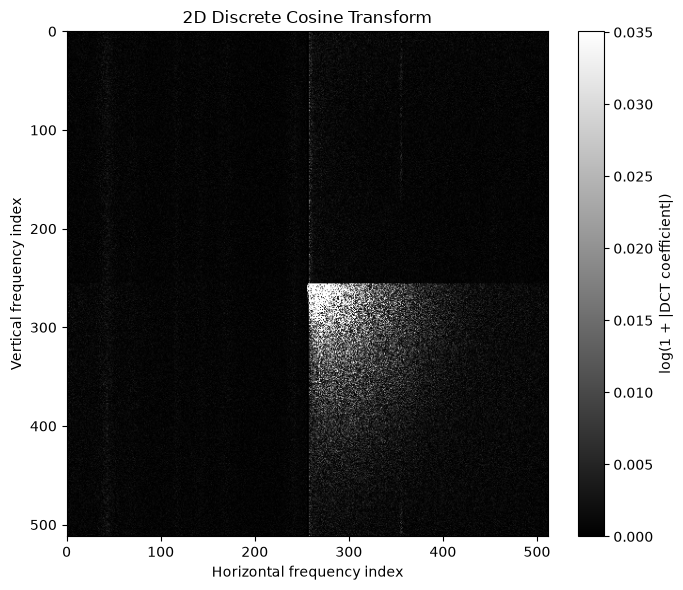

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import dctn

z = np.asarray(z_destriped_2d, dtype=float)

# Remove the average height so the DC coefficient does not dominate
z_centered = z - np.mean(z)

# 2D DCT
z_dct = dctn(z_centered, type=2, norm="ortho")
z_shifted=np.fft.fftshift(z_dct) 

# Log-scaled magnitude
dct_display = np.log1p(np.abs(z_shifted))*10e6

plt.close("all")

fig, ax = plt.subplots(figsize=(7, 6))

image = ax.imshow(
    dct_display,
    cmap="gray",
    origin="upper",
    aspect="auto",
    vmin=0,
    vmax=np.percentile(dct_display, 99.5)
)

ax.set_xlim(0, z.shape[1])
ax.set_ylim(z.shape[0], 0)

ax.set_title("2D Discrete Cosine Transform")
ax.set_xlabel("Horizontal frequency index")
ax.set_ylabel("Vertical frequency index")

fig.colorbar(image, ax=ax, label="log(1 + |DCT coefficient|)")
plt.tight_layout()
plt.show()

## Discrete Hartley Transform

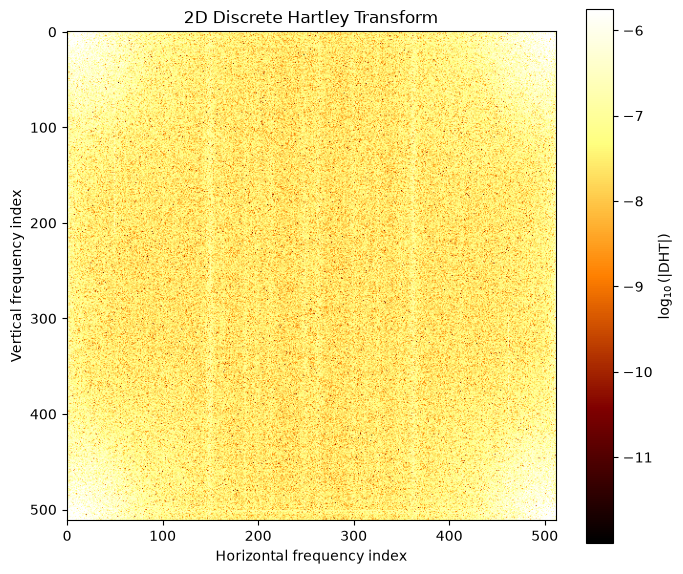

In [10]:
# 2D Discrete Hartley Transform
z_dht = F.real - F.imag

# Centre zero frequency for display
z_dht_shifted = np.fft.fftshift(z_dht)

# Log-scaled magnitude
dht_display = np.log10(np.abs(z_dht_shifted) + 1e-12)

plt.figure(figsize=(7, 6))

plt.imshow(
    dht_display,
    cmap="afmhot",
    origin="upper",
    vmax=np.percentile(dht_display, 99.5)
)

plt.colorbar(label=r"$\log_{10}(|\mathrm{DHT}|)$")
plt.title("2D Discrete Hartley Transform")
plt.xlabel("Horizontal frequency index")
plt.ylabel("Vertical frequency index")
plt.tight_layout()
plt.show()

But then, I learned that Hartley is mainly a real-valued alternative representation of the Fourier transform. Its traditional advantage was avoiding complex arithmetic, but modern FFT libraries already handle complex calculations efficiently. SO, it is a bit useless when it comes to analying GaN quantum dot Properties

## Introductory wavelets: the Gabor wavelet 

In [11]:
from scipy.ndimage import gaussian_filter
from skimage.filters import gabor
from skimage.feature import peak_local_max
from skimage.exposure import rescale_intensity
from skimage.morphology import white_tophat, disk


# Replace invalid values
median_height = np.nanmedian(z_destriped_2d)
z_destriped_2d = np.nan_to_num(z_destriped_2d, nan=median_height)

# Removing the mean removes only the constant height offset
z_nobackground = z_destriped_2d - np.mean(z_destriped_2d)

# Very light smoothing: stronger smoothing could erase 1–2 pixel dots
z_smooth = gaussian_filter(z_nobackground, sigma=0.58)

# Scale to 0–1 so filter thresholds are easier to interpret
z_normalised = rescale_intensity(
    z_smooth,
    in_range="image",
    out_range=(0.0, 1.0)
)

**1. Suppress the large GaN areas**

In [12]:
# A top-hat with a radius larger than most dots preserves small bright structures while suppressing broad background and large GaN.
small_feature_image = white_tophat(
    z_normalised,
    footprint=disk(6)
)

small_feature_image = rescale_intensity(
    small_feature_image,
    in_range="image",
    out_range=(0.0, 1.0)
)

**2. Create the Gabor filter bank for quantum dot detection**

In [13]:
# A 1-pixel feature cannot be represented reliably as a spatial oscillation. So have to start counting the quantum dots from wavelength = 2 pixels.
wavelengths = [2, 3, 4, 5, 6, 8]
orientations = np.linspace( 0, np.pi, 8, endpoint=False)

# Create a small array with the same shale as the small_feature_image with the same data type, but this one will initially be having zeroes only 
combined_response = np.zeros_like(small_feature_image)

# Save selected responses so that we can display the transform itself
response_maps = {}

for wavelength in wavelengths:

    frequency = 1.0 / wavelength

    for theta in orientations:

        real_response, imaginary_response = gabor(
            small_feature_image,
            frequency=frequency,
            theta=theta,
            bandwidth=1.0
        )

        # Phase-independent response magnitude
        magnitude = np.sqrt(real_response**2 + imaginary_response**2)

        # Keep the strongest filter response at every pixel
        combined_response = np.maximum(combined_response, magnitude)

        # Store a few representative transform channels
        if wavelength in [3, 5, 8] and np.isclose(theta, 0):
            response_maps[(wavelength, 0)] = magnitude


**3. Detect local maxima in the Gabor response**

In [14]:
threshold = np.percentile(combined_response, 90)

coordinates = peak_local_max(
    combined_response,
    min_distance=2,
    threshold_abs=threshold,
    exclude_border=False
)

print("Candidate quantum dots:", len(coordinates))

Candidate quantum dots: 423


**4. Display individual Gabor transform channels**

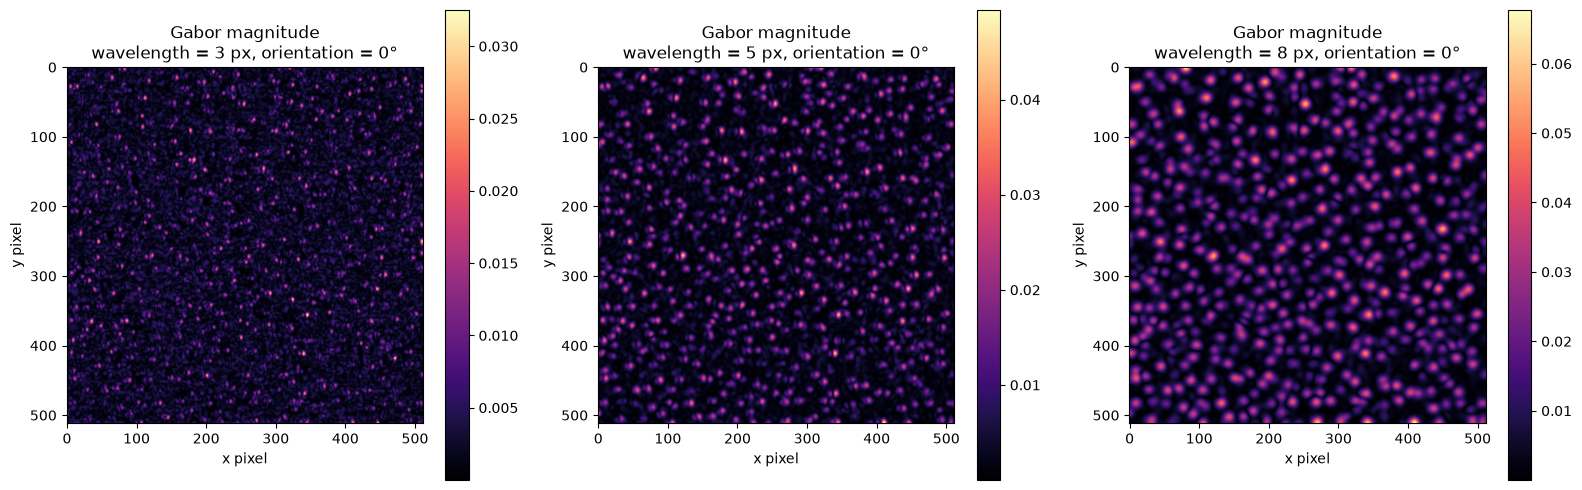

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, ((wavelength, theta), response) in zip(
    axes,
    response_maps.items()
):
    image = ax.imshow(response, cmap="magma", origin="upper")

    ax.set_title(
        f"Gabor magnitude\n"
        f"wavelength = {wavelength} px, orientation = 0°"
    )
    ax.set_xlabel("x pixel")
    ax.set_ylabel("y pixel")

    fig.colorbar(image, ax=ax)

plt.tight_layout()
plt.show()


Display AFM, Gabor response, and detected Gabor blobs

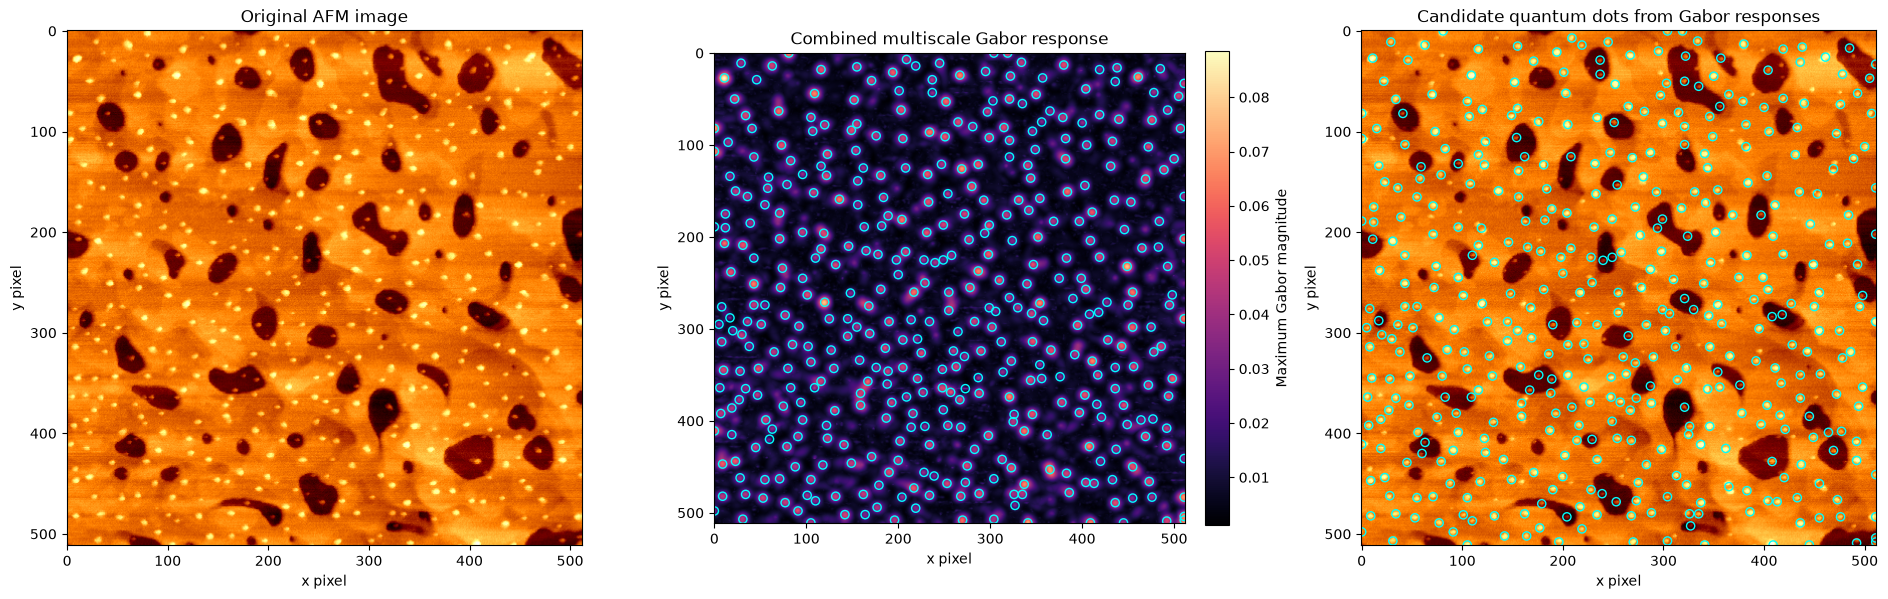

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(19, 6))


# Displaying the original AFM plot
axes[0].imshow( z_destriped_2d, cmap="afmhot", origin="upper")
axes[0].set_title("Original AFM image")
axes[0].set_xlabel("x pixel")
axes[0].set_ylabel("y pixel")


# Displaying the combined Gabor response 
gabor_image = axes[1].imshow(combined_response, cmap="magma", origin="upper")

axes[1].scatter(
    coordinates[:, 1],
    coordinates[:, 0],
    facecolors="none",
    edgecolors="cyan",
    s=35,
    linewidths=1
)

axes[1].set_title("Combined multiscale Gabor response")
axes[1].set_xlabel("x pixel")
axes[1].set_ylabel("y pixel")

fig.colorbar(
    gabor_image,
    ax=axes[1],
    label="Maximum Gabor magnitude",
    fraction=0.046, # Sets the colorbar width relative to the subplot size. Smaller values make the colorbar thinner.
    pad=0.04, # Sets the gap between the image and the colorbar
)


# Displaying blobs due to Gabor wavelenght max response on the original AFM plot, drawing the blobs around detected QDs
axes[2].imshow(
    z_destriped_2d,
    cmap="afmhot",
    origin="upper"
)
axes[2].scatter(
    coordinates[:, 1],
    coordinates[:, 0],
    facecolors="none",
    edgecolors="cyan",
    s=35,
    linewidths=1
)
axes[2].set_title("Candidate quantum dots from Gabor responses")
axes[2].set_xlabel("x pixel")
axes[2].set_ylabel("y pixel")

plt.tight_layout()
plt.show()

I felt like this worked pretty well, considering this is just a space transformation.. and we chose the threshold of a dot to be 90%.

So, have decided to look at some histograms for Gabos magnitudes and detected peaks. **Then, after labelling, it would be interesting to look at the probability of a dot given its gabor magnitude.**

A different idea could be to decrease the Gaussian smoothing parameter, and try rotating the gabor wavelets to see if this would also give the same number of dots. Assigning different weights vertically and horizontally to Gabor wavelets could work too - this would account for fast and slow scan directions, making it easier to use the striped version rather than jumping straight to the destriped one. 

### Histograms and overall dot count

Overall number of detected dot candidates: 423


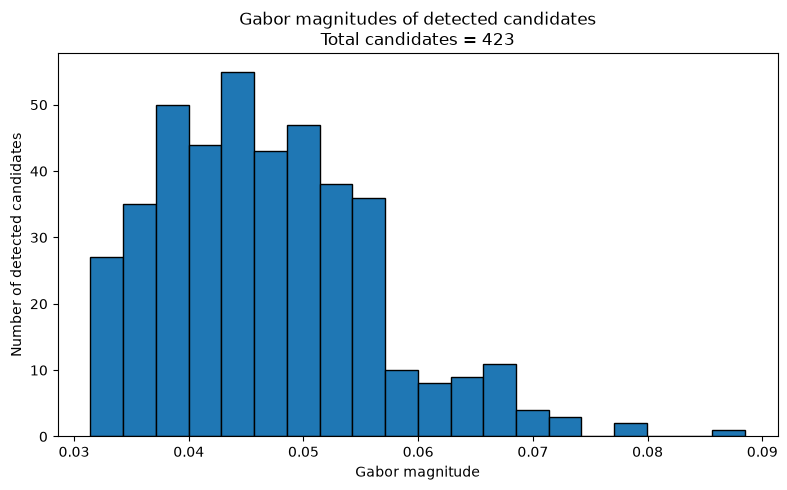

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from skimage.feature import peak_local_max


# Find candidate dot centres

threshold = np.percentile(combined_response, 90)

dot_coordinates = peak_local_max(
    combined_response,
    min_distance=2,
    threshold_abs=threshold,
    exclude_border=False
)

# Gabor magnitude at every detected centre
dot_magnitudes = combined_response[
    dot_coordinates[:, 0],
    dot_coordinates[:, 1]
]

print("Overall number of detected dot candidates:", len(dot_coordinates))


# Histogram of candidate magnitudes

plt.figure(figsize=(8, 5))

counts, bin_edges, _ = plt.hist(
    dot_magnitudes,
    bins=20,
    edgecolor="black"
)

plt.xlabel("Gabor magnitude")
plt.ylabel("Number of detected candidates")
plt.title(
    f"Gabor magnitudes of detected candidates\n"
    f"Total candidates = {len(dot_coordinates)}"
)

plt.tight_layout()
plt.show()

Inspecting the relative Gabor magnitude distributions for different thresholds of the QD detection: 

In [18]:
finite_response = combined_response[np.isfinite(combined_response)]

print( "Minimum:", np.min(finite_response),)

print( "Median:", np.median(finite_response),)

for percentile in [ 75, 85, 90, 95, 97, 99, 99.5,]:
    print(
        f"{percentile}th percentile:",
        np.percentile(finite_response,percentile,),
    )

print("Maximum:", np.max(finite_response),)

Minimum: 0.0012457624969350388
Median: 0.01056006021537718
75th percentile: 0.019036926404710594
85th percentile: 0.026062713239487438
90th percentile: 0.03116221424161692
95th percentile: 0.03849856085551394
97th percentile: 0.04288229270146207
99th percentile: 0.050593256500145456
99.5th percentile: 0.0550276588072891
Maximum: 0.08850470047616807


* 75% of pixels have Gabor magnitude less than or equal to 0.012
* 90% of pixels have magnitude less than or equal to 0.021
* 95% are less than or equal to 0.030
* 99% are less than or equal to 0.055

**Equivalently:**
* only the strongest 25% of pixels are above the 75th percentile
* only the strongest 10% are above the 90th percentile
* only the strongest 5% are above the 95th percentile
* only the strongest 1% are above the 99th percentile